In [6]:
import pandas as pd


results = pd.read_csv("archive/results.csv")
qualifying = pd.read_csv("archive/qualifying.csv")
races = pd.read_csv("archive/races.csv")
circuits = pd.read_csv("archive/circuits.csv")
status = pd.read_csv('archive/status.csv')

In [7]:
# Juntamos los archivos para tener nuestro dataset con todas las columnas que necesitamos


df = results.merge(qualifying, on=['raceId', 'driverId'], how='inner')
df = df.merge(races[['raceId', 'circuitId', 'year']], on='raceId', how='left')
df = df.merge(circuits[['circuitId', 'name', 'location']], on='circuitId', how='left')
df = df.merge(status, on='statusId', how='left')




df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10494 entries, 0 to 10493
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         10494 non-null  int64  
 1   raceId           10494 non-null  int64  
 2   driverId         10494 non-null  int64  
 3   constructorId_x  10494 non-null  int64  
 4   number_x         10494 non-null  str    
 5   grid             10494 non-null  int64  
 6   position_x       10494 non-null  str    
 7   positionText     10494 non-null  str    
 8   positionOrder    10494 non-null  int64  
 9   points           10494 non-null  float64
 10  laps             10494 non-null  int64  
 11  time             10494 non-null  str    
 12  milliseconds     10494 non-null  str    
 13  fastestLap       10494 non-null  str    
 14  rank             10494 non-null  str    
 15  fastestLapTime   10494 non-null  str    
 16  fastestLapSpeed  10494 non-null  str    
 17  statusId         10494 

In [8]:
#hacemos un dataset con las variables que me importan para mi analisis (no incluimos variables muy especificas que no vamos a usar)
df_clean = df[[
   'raceId',
   'driverId',
   'grid',
   'positionOrder',
   'circuitId',
   'name',
   'year',
   'status'
]]


df_clean.info()


<class 'pandas.DataFrame'>
RangeIndex: 10494 entries, 0 to 10493
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   raceId         10494 non-null  int64
 1   driverId       10494 non-null  int64
 2   grid           10494 non-null  int64
 3   positionOrder  10494 non-null  int64
 4   circuitId      10494 non-null  int64
 5   name           10494 non-null  str  
 6   year           10494 non-null  int64
 7   status         10494 non-null  str  
dtypes: int64(6), str(2)
memory usage: 656.0 KB


In [9]:
#filtramos los que si terminaron la carrera
df_clean = df_clean[df_clean['status'] == 'Finished']


df_clean.info()


<class 'pandas.DataFrame'>
Index: 4707 entries, 0 to 10483
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   raceId         4707 non-null   int64
 1   driverId       4707 non-null   int64
 2   grid           4707 non-null   int64
 3   positionOrder  4707 non-null   int64
 4   circuitId      4707 non-null   int64
 5   name           4707 non-null   str  
 6   year           4707 non-null   int64
 7   status         4707 non-null   str  
dtypes: int64(6), str(2)
memory usage: 331.0 KB


In [10]:
#creamos nueva variable, que nos diga la diferencia entre posicion de largada y posicion en la que termino
df_clean['diferencia_posicion'] = df_clean['grid'] - df_clean['positionOrder']
df_clean['diferencia_posiciones'] = df_clean['grid'] - df_clean['positionOrder']
df_clean[['grid', 'positionOrder', 'diferencia_posiciones']].head()




,grid,positionOrder,diferencia_posiciones
0,1,1,0
1,5,2,3
2,7,3,4
3,11,4,7
4,3,5,-2


In [11]:
#chequeamos que circuitos hay en el dataset
df_clean['name'].unique()


<StringArray>
[      'Albert Park Grand Prix Circuit',
         'Sepang International Circuit',
        'Bahrain International Circuit',
       'Circuit de Barcelona-Catalunya',
                        'Istanbul Park',
                    'Circuit de Monaco',
            'Circuit Gilles Villeneuve',
        'Circuit de Nevers Magny-Cours',
                  'Silverstone Circuit',
                       'Hockenheimring',
                          'Hungaroring',
              'Valencia Street Circuit',
         'Circuit de Spa-Francorchamps',
         'Autodromo Nazionale di Monza',
            'Marina Bay Street Circuit',
                        'Fuji Speedway',
       'Shanghai International Circuit',
           'Autódromo José Carlos Pace',
          'Indianapolis Motor Speedway',
                          'Nürburgring',
        'Autodromo Enzo e Dino Ferrari',
                       'Suzuka Circuit',
                        'Red Bull Ring',
        'Autódromo Juan y Oscar Gálvez',
  

In [12]:
#despues de que chat nos diga que circuito es de cada tipo
# clasificamos los circuitos en urbano, hibrido, permanente.
tipo_circuito = {
   # 🏙 Urbanos
   'Circuit de Monaco': 'urbano',
   'Valencia Street Circuit': 'urbano',
   'Marina Bay Street Circuit': 'urbano',
   'Baku City Circuit': 'urbano',
   'Jeddah Corniche Circuit': 'urbano',
   'Las Vegas Strip Street Circuit': 'urbano',
   'Adelaide Street Circuit': 'urbano',


   # 🔀 Híbridos
   'Albert Park Grand Prix Circuit': 'hibrido',
   'Sochi Autodrom': 'hibrido',
   'Miami International Autodrome': 'hibrido',
   'Autódromo Hermanos Rodríguez': 'hibrido',


   # 🏁 Permanentes (el resto)
   'Sepang International Circuit': 'permanente',
   'Bahrain International Circuit': 'permanente',
   'Circuit de Barcelona-Catalunya': 'permanente',
   'Istanbul Park': 'permanente',
   'Circuit Gilles Villeneuve': 'permanente',
   'Circuit de Nevers Magny-Cours': 'permanente',
   'Silverstone Circuit': 'permanente',
   'Hockenheimring': 'permanente',
   'Hungaroring': 'permanente',
   'Circuit de Spa-Francorchamps': 'permanente',
   'Autodromo Nazionale di Monza': 'permanente',
   'Fuji Speedway': 'permanente',
   'Shanghai International Circuit': 'permanente',
   'Autódromo José Carlos Pace': 'permanente',
   'Indianapolis Motor Speedway': 'permanente',
   'Nürburgring': 'permanente',
   'Autodromo Enzo e Dino Ferrari': 'permanente',
   'Suzuka Circuit': 'permanente',
   'Red Bull Ring': 'permanente',
   'Autódromo Juan y Oscar Gálvez': 'permanente',
   'Autódromo do Estoril': 'permanente',
   'Okayama International Circuit': 'permanente',
   'Circuito de Jerez': 'permanente',
   'Yas Marina Circuit': 'permanente',
   'Korean International Circuit': 'permanente',
   'Buddh International Circuit': 'permanente',
   'Circuit of the Americas': 'permanente',
   'Circuit Paul Ricard': 'permanente',
   'Autodromo Internazionale del Mugello': 'permanente',
   'Autódromo Internacional do Algarve': 'permanente',
   'Circuit Park Zandvoort': 'permanente',
   'Losail International Circuit': 'permanente'
}




In [13]:
#lo aplicamos al dataset, creando esta nueva columna
df_clean['tipo_circuito'] = df_clean['name'].map(tipo_circuito)

#vemos cuantos hay de cada uno
df_clean['tipo_circuito'].value_counts()



tipo_circuito
permanente    3653
urbano         634
hibrido        420
Name: count, dtype: int64

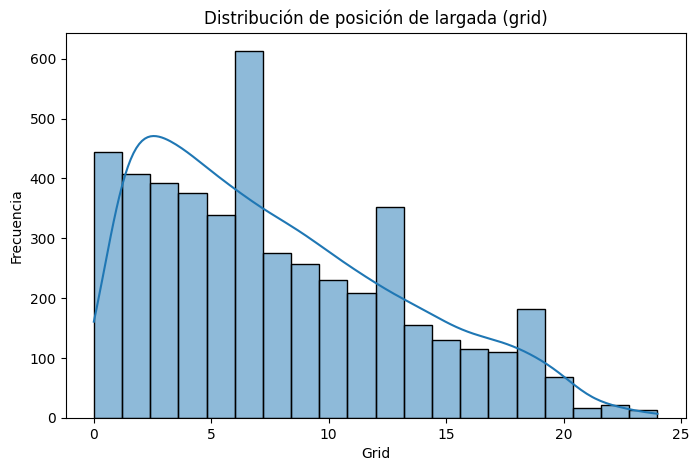

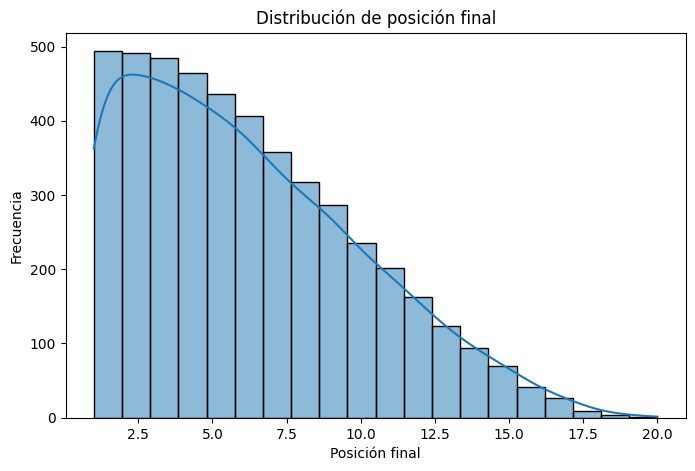

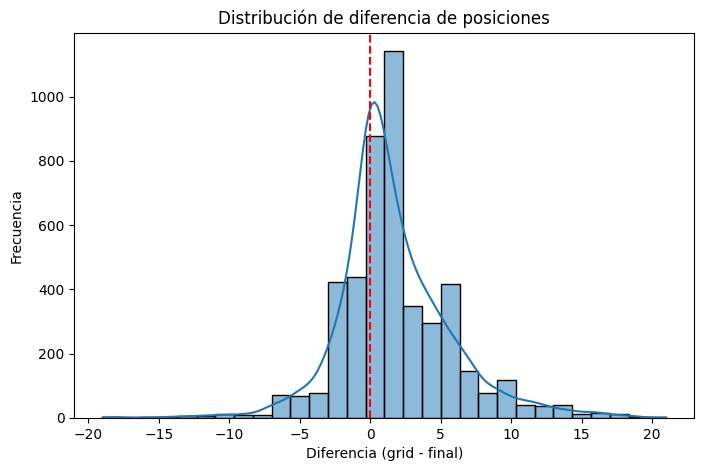

In [14]:
#analizamos variables por separado, para entender su comportamiento
import seaborn as sns
import matplotlib.pyplot as plt


#grid
plt.figure(figsize=(8,5))
sns.histplot(df_clean['grid'], bins=20, kde=True)
plt.title('Distribución de posición de largada (grid)')
plt.xlabel('Grid')
plt.ylabel('Frecuencia')
plt.show()


#positionOrder
plt.figure(figsize=(8,5))
sns.histplot(df_clean['positionOrder'], bins=20, kde=True)
plt.title('Distribución de posición final')
plt.xlabel('Posición final')
plt.ylabel('Frecuencia')
plt.show()


#diferencia_posiciones
plt.figure(figsize=(8,5))
sns.histplot(df_clean['diferencia_posiciones'], bins=30, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribución de diferencia de posiciones')
plt.xlabel('Diferencia (grid - final)')
plt.ylabel('Frecuencia')
plt.show()




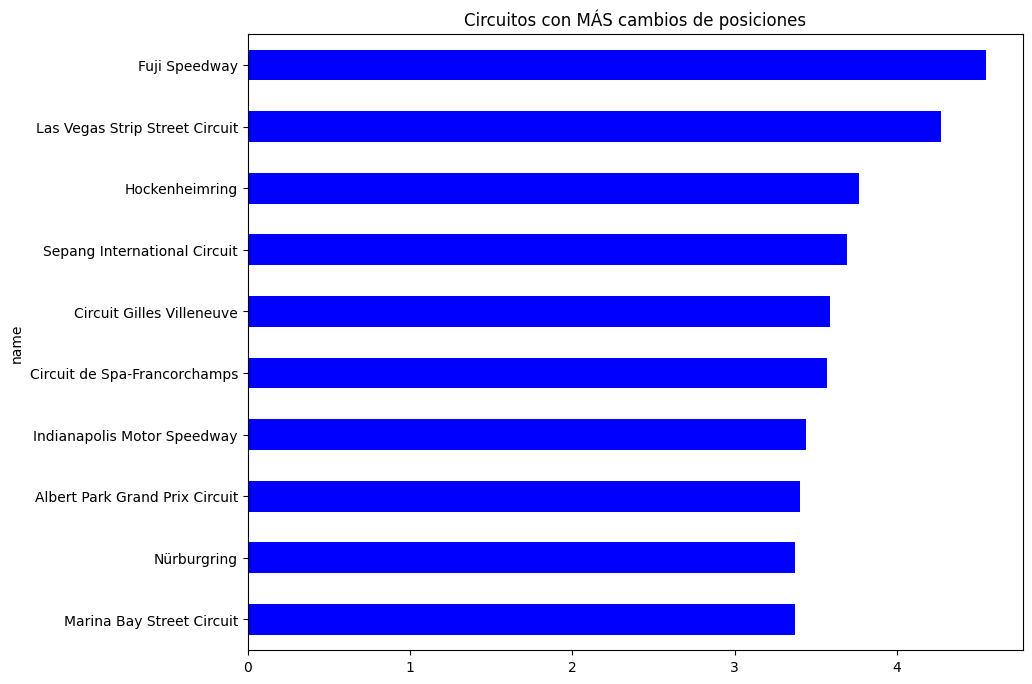

In [15]:


df_clean['movimiento_absoluto'] = df_clean['diferencia_posiciones'].abs()
movimiento_circuito = df_clean.groupby('name')['movimiento_absoluto'].mean().sort_values()


plt.figure(figsize=(10,8))
movimiento_circuito.tail(10).plot(kind='barh', color='blue')
plt.title('Circuitos con MÁS cambios de posiciones')
plt.show()




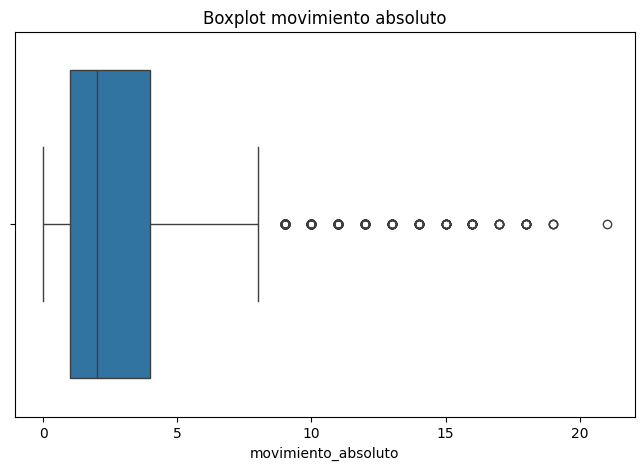

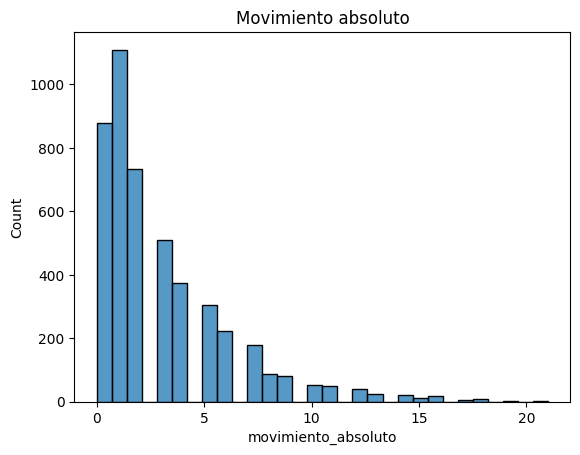

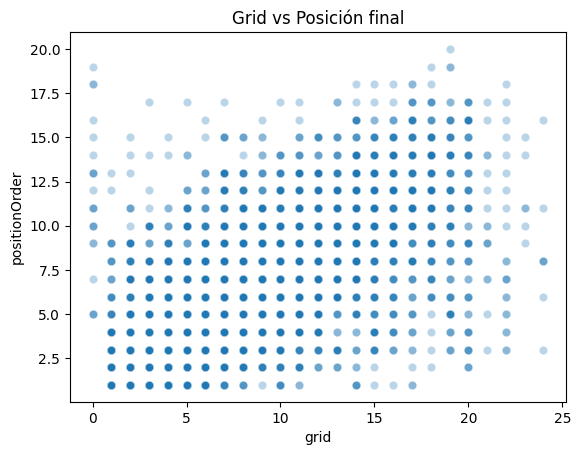

In [16]:
#Boxplots
plt.figure(figsize=(8,5))
sns.boxplot(x=df_clean['movimiento_absoluto'])
plt.title('Boxplot movimiento absoluto')
plt.show()




sns.histplot(df_clean['movimiento_absoluto'], bins=30)
plt.title('Movimiento absoluto')
plt.show()



sns.scatterplot(
   x=df_clean['grid'],
   y=df_clean['positionOrder'],
   alpha=0.3
)
plt.title('Grid vs Posición final')
plt.show()



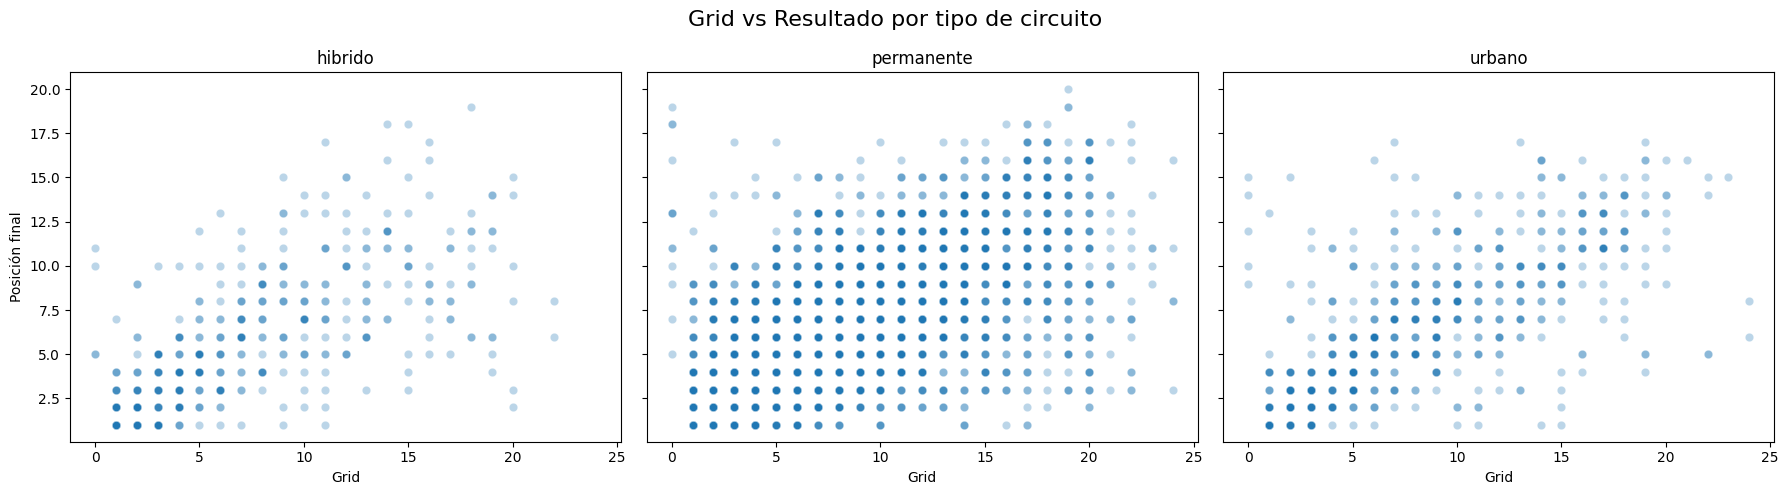

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt


tipos = df_clean['tipo_circuito'].unique()


fig, axes = plt.subplots(1, len(tipos), figsize=(18,5), sharex=True, sharey=True)


for i, tipo in enumerate(tipos):
  
   df_tipo = df_clean[df_clean['tipo_circuito'] == tipo]
  
   sns.scatterplot(
       data=df_tipo,
       x='grid',
       y='positionOrder',
       alpha=0.3,
       ax=axes[i]
   )
  
   axes[i].set_title(f'{tipo}')
   axes[i].set_xlabel('Grid')
   axes[i].set_ylabel('Posición final')


plt.suptitle('Grid vs Resultado por tipo de circuito', fontsize=16)
plt.tight_layout()
plt.show()



In [18]:
correlacion_tipo = df_clean.groupby('tipo_circuito').apply(
   lambda x: x['grid'].corr(x['positionOrder'])
)

correlacion_tipo



tipo_circuito
hibrido       0.647289
permanente    0.663520
urbano        0.682884
dtype: float64

In [19]:
ranking = df_clean.groupby('name')['movimiento_absoluto'].mean().sort_values()
ranking.head(10)  # menos movimiento


name
Autódromo do Estoril                  1.545455
Okayama International Circuit         1.600000
Circuit de Nevers Magny-Cours         1.677419
Autódromo Internacional do Algarve    1.866667
Autódromo Hermanos Rodríguez          2.013514
Circuit de Barcelona-Catalunya        2.043956
Circuit Paul Ricard                   2.190476
Buddh International Circuit           2.393939
Yas Marina Circuit                    2.407609
Circuit de Monaco                     2.548223
Name: movimiento_absoluto, dtype: float64

In [20]:
ranking.tail(10)  # más movimiento


name
Marina Bay Street Circuit         3.370166
Nürburgring                       3.372549
Albert Park Grand Prix Circuit    3.401869
Indianapolis Motor Speedway       3.437500
Circuit de Spa-Francorchamps      3.570423
Circuit Gilles Villeneuve         3.589189
Sepang International Circuit      3.690141
Hockenheimring                    3.762590
Las Vegas Strip Street Circuit    4.272727
Fuji Speedway                     4.545455
Name: movimiento_absoluto, dtype: float64

/var/folders/jl/kbwq2_l93wz2xhy4h9sbl25w0000gn/T/ipykernel_57136/2287552529.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


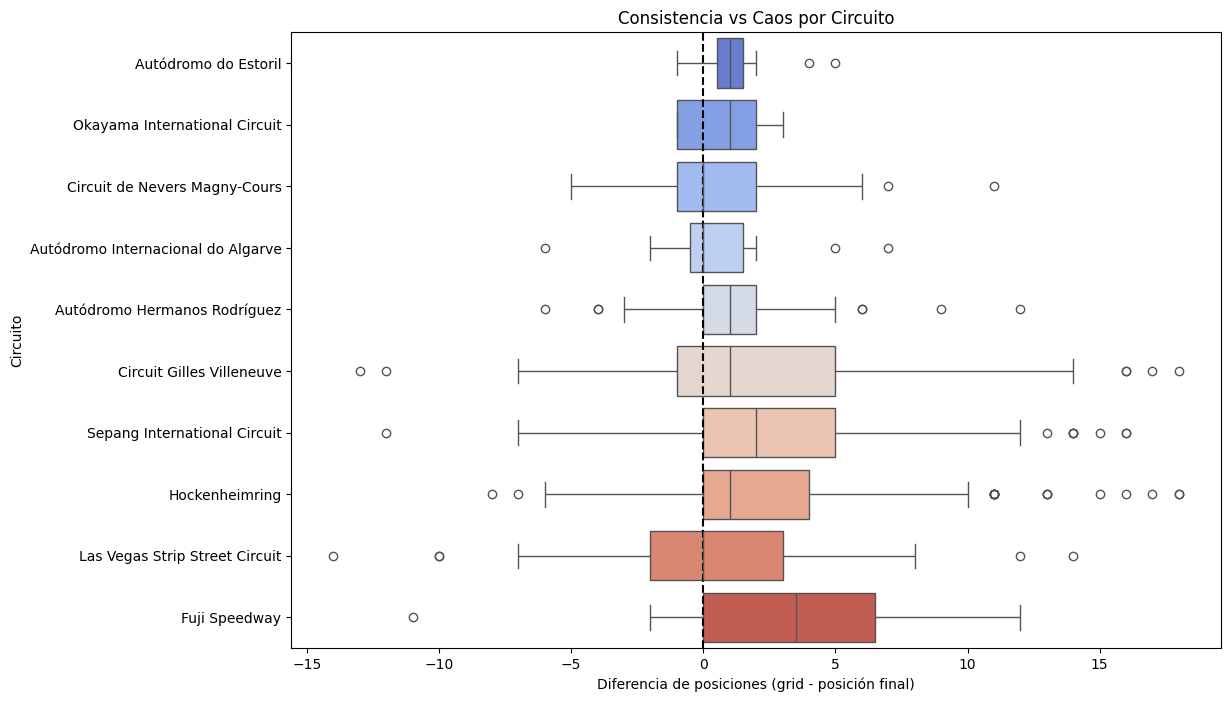

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Seleccionamos extremos del ranking
top_estaticos = ranking.head(5).index.tolist()   # menos movimiento
top_caoticos = ranking.tail(5).index.tolist()   # más movimiento

circuitos_seleccionados = top_estaticos + top_caoticos

# 2. Filtramos el dataset
df_box = df_clean[df_clean['name'].isin(circuitos_seleccionados)]

# 3. Creamos el boxplot
plt.figure(figsize=(12, 8))

sns.boxplot(
    data=df_box,
    x='diferencia_posiciones',
    y='name',
    order=circuitos_seleccionados,
    palette='coolwarm'
)

# 4. Línea en 0 (referencia)
plt.axvline(0, color='black', linestyle='--')

# 5. Labels
plt.title('Consistencia vs Caos por Circuito')
plt.xlabel('Diferencia de posiciones (grid - posición final)')
plt.ylabel('Circuito')

plt.show()

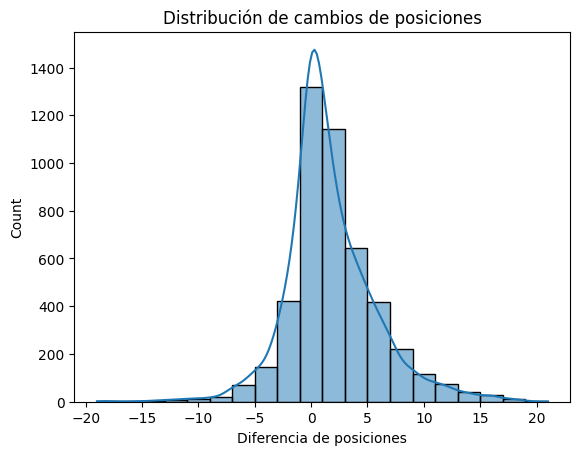

In [22]:
df_clean['diferencia_posiciones']

sns.histplot(df_clean['diferencia_posiciones'], bins=20, kde=True)
plt.title('Distribución de cambios de posiciones')
plt.xlabel('Diferencia de posiciones')
plt.show()

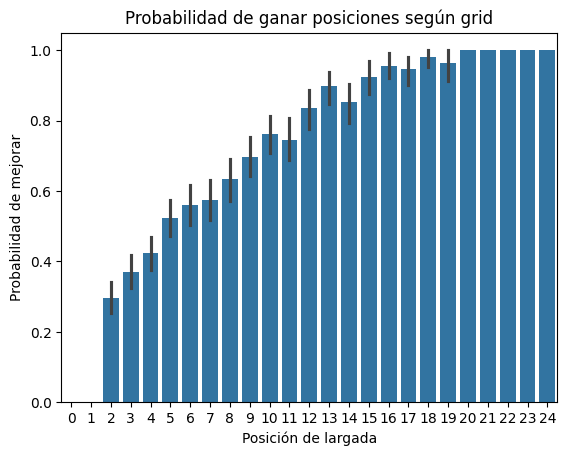

In [24]:
df_clean['mejora'] = df_clean['diferencia_posiciones'] > 0

sns.barplot(
    data=df_clean,
    x='grid',
    y='mejora'
)

plt.title('Probabilidad de ganar posiciones según grid')
plt.ylabel('Probabilidad de mejorar')
plt.xlabel('Posición de largada')

plt.show()

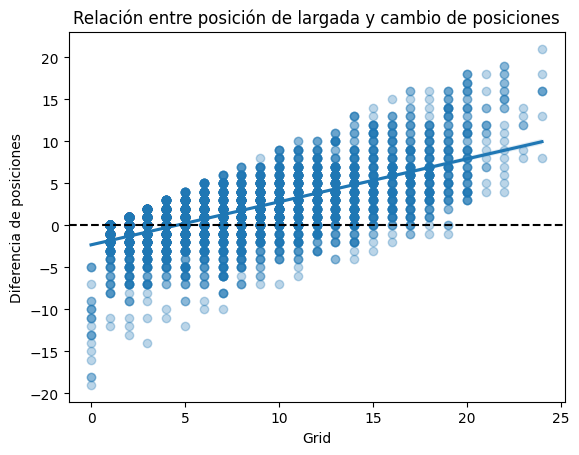

In [25]:
sns.regplot(
    data=df_clean,
    x='grid',
    y='diferencia_posiciones',
    scatter_kws={'alpha':0.3}
)

plt.axhline(0, linestyle='--', color='black')

plt.title('Relación entre posición de largada y cambio de posiciones')
plt.xlabel('Grid')
plt.ylabel('Diferencia de posiciones')

plt.show()